In [1]:
%pip install shap

  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.5.0 requires daal==2021.4.0, which is not installed.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import shap

RANDOM_STATE = 42

In [3]:
df = pd.read_csv("survey.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1259, 27)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 1259
Number of columns: 27

Column names:
['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments']


In [5]:
print(df.info())
print(df.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [6]:
print(df["treatment"].value_counts(dropna=False))

print("\nPercentage distribution:")
print(
    df["treatment"]
    .value_counts(normalize=True, dropna=False) * 100
)

Yes    637
No     622
Name: treatment, dtype: int64

Percentage distribution:
Yes    50.595711
No     49.404289
Name: treatment, dtype: float64


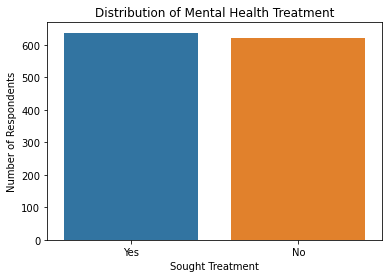

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="treatment"
)

plt.title("Distribution of Mental Health Treatment")
plt.xlabel("Sought Treatment")
plt.ylabel("Number of Respondents")

plt.show()

The target classes are reasonably represented, but the distribution is not perfectly balanced. Stratification and class-sensitive evaluation metrics were therefore used to reduce the risk of misleading performance estimates.

In [8]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    )
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
comments,1095,86.973789
state,515,40.905481
work_interfere,264,20.969023
self_employed,18,1.429706
seek_help,0,0.000000
obs_consequence,0,0.000000
mental_vs_physical,0,0.000000
phys_health_interview,0,0.000000
mental_health_interview,0,0.000000
supervisor,0,0.000000


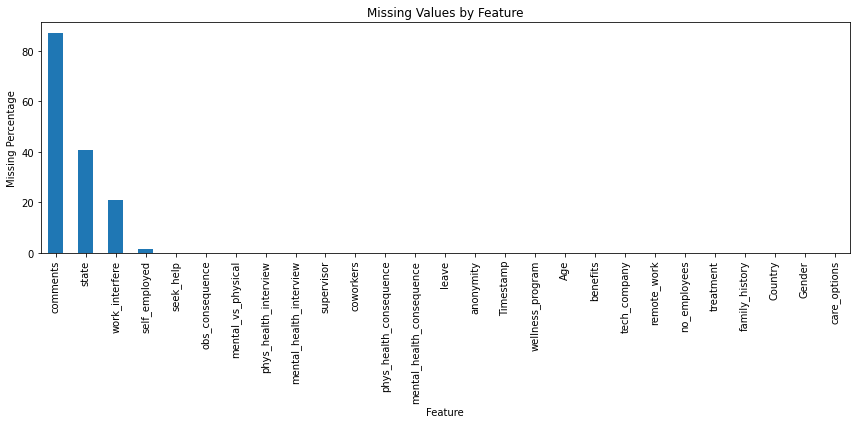

In [9]:
plt.figure(figsize=(12, 6))

missing_summary["Missing Percentage"].plot(
    kind="bar"
)

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Percentage")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [10]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
print(df.dtypes)

Timestamp                    object
Age                           int64
Gender                       object
Country                      object
state                        object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_health_interview        object
mental_vs_physical           object
obs_consequence              object
comments                     object
dtype: object


In [12]:
print(df["Age"].describe())

print("\nUnique age values:")
print(sorted(df["Age"].dropna().unique()))

df["Age"] = pd.to_numeric(
    df["Age"],
    errors="coerce"
)

count    1.259000e+03
mean     7.942815e+07
std      2.818299e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64

Unique age values:
[-1726, -29, -1, 5, 8, 11, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 53, 54, 55, 56, 57, 58, 60, 61, 62, 65, 72, 329, 99999999999]


In [13]:
invalid_age_count = (
    (df["Age"] < 18) |
    (df["Age"] > 100)
).sum()

print(
    "Number of invalid age values:",
    invalid_age_count
)

Number of invalid age values: 8


In [14]:
df.loc[
    (df["Age"] < 18) |
    (df["Age"] > 100),
    "Age"
] = np.nan

print(df["Age"].describe())

count    1251.000000
mean       32.076739
std         7.288272
min        18.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        72.000000
Name: Age, dtype: float64


In [117]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for col in categorical_columns:
    print("\n" + "=" * 60)
    print(col)
    print(df[col].value_counts(dropna=False).head(5))


Gender
Male      979
Female    243
Other      37
Name: Gender, dtype: int64

self_employed
No     1095
Yes     146
NaN      18
Name: self_employed, dtype: int64

family_history
No     767
Yes    492
Name: family_history, dtype: int64

treatment
Yes    637
No     622
Name: treatment, dtype: int64

work_interfere
Sometimes    465
NaN          264
Never        213
Rarely       173
Often        144
Name: work_interfere, dtype: int64

no_employees
6-25              290
26-100            289
More than 1000    282
100-500           176
1-5               162
Name: no_employees, dtype: int64

remote_work
No     883
Yes    376
Name: remote_work, dtype: int64

tech_company
Yes    1031
No      228
Name: tech_company, dtype: int64

benefits
Yes           477
Don't know    408
No            374
Name: benefits, dtype: int64

care_options
No          501
Yes         444
Not sure    314
Name: care_options, dtype: int64

wellness_program
No            842
Yes           229
Don't know    188
Name: welln

In [16]:
def clean_gender(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    if value in [
        "male",
        "m",
        "man",
        "cis male",
        "cis-male"
    ]:
        return "Male"

    elif value in [
        "female",
        "f",
        "woman",
        "cis female",
        "cis-female"
    ]:
        return "Female"

    else:
        return "Other"

df["Gender"] = df["Gender"].apply(clean_gender)

print(
    df["Gender"]
    .value_counts(dropna=False)
)

Male      979
Female    243
Other      37
Name: Gender, dtype: int64


In [17]:
columns_to_drop = [
    "Timestamp",
    "comments",
    "state",
    "Country"
]

df = df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

print("Shape after dropping columns:", df.shape)

Shape after dropping columns: (1259, 23)


In [18]:
def create_age_group(age):

    if pd.isna(age):
        return "Unknown"

    elif age < 25:
        return "18-24"

    elif age < 35:
        return "25-34"

    elif age < 45:
        return "35-44"

    elif age < 55:
        return "45-54"

    else:
        return "55+"

df["Age_Group"] = df["Age"].apply(
    create_age_group
)

df[
    ["Age", "Age_Group"]
].head(10)

,Age,Age_Group
0,37.0,35-44
1,44.0,35-44
2,32.0,25-34
3,31.0,25-34
4,31.0,25-34
5,33.0,25-34
6,35.0,35-44
7,39.0,35-44
8,42.0,35-44
9,23.0,18-24


In [19]:
support_columns = [
    "benefits",
    "care_options",
    "wellness_program",
    "seek_help"
]

for col in support_columns:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 benefits
Yes           477
Don't know    408
No            374
Name: benefits, dtype: int64

 care_options
No          501
Yes         444
Not sure    314
Name: care_options, dtype: int64

 wellness_program
No            842
Yes           229
Don't know    188
Name: wellness_program, dtype: int64

 seek_help
No            646
Don't know    363
Yes           250
Name: seek_help, dtype: int64


In [20]:
support_map = {
    "Yes": 1,
    "No": 0,
    "Don't know": 0,
    "Not sure": 0,
    "Somewhat easy": 1,
    "Very easy": 1,
    "Somewhat difficult": 0,
    "Very difficult": 0
}

df["Workplace_Support_Score"] = 0

for col in support_columns:

    if col in df.columns:

        df["Workplace_Support_Score"] += (
            df[col]
            .map(support_map)
            .fillna(0)
        )

print(
    df["Workplace_Support_Score"]
    .value_counts()
    .sort_index()
)

0    589
1    263
2    194
3    103
4    110
Name: Workplace_Support_Score, dtype: int64


In [21]:
df["Family_History_Flag"] = (
    df["family_history"]
    .map({
        "Yes": 1,
        "No": 0
    })
)

df["Work_Interference_Flag"] = (
    df["work_interfere"]
    .map({
        "Never": 0,
        "Rarely": 1,
        "Sometimes": 1,
        "Often": 1
    })
)

In [22]:
print("Final dataset shape:", df.shape)

df.head()

Final dataset shape: (1259, 27)


,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Age_Group,Workplace_Support_Score,Family_History_Flag,Work_Interference_Flag
0,37.0,Female,NaN,No,Yes,Often,6-25,No,Yes,Yes,...,Some of them,Yes,No,Maybe,Yes,No,35-44,2,0,1.0
1,44.0,Male,NaN,No,No,Rarely,More than 1000,No,No,Don't know,...,No,No,No,No,Don't know,No,35-44,0,0,1.0
2,32.0,Male,NaN,No,No,Rarely,6-25,No,Yes,No,...,Yes,Yes,Yes,Yes,No,No,25-34,0,0,1.0
3,31.0,Male,NaN,Yes,Yes,Often,26-100,No,Yes,No,...,Some of them,No,Maybe,Maybe,No,Yes,25-34,1,1,1.0
4,31.0,Male,NaN,No,No,Never,100-500,Yes,Yes,Yes,...,Some of them,Yes,Yes,Yes,Don't know,No,25-34,1,0,0.0


Missing values and categorical variables were handled through the preprocessing pipeline, while domain-informed features such as family-history, work-interference, workplace-support score, and age group were engineered. The pipeline was fitted only on training data to prevent leakage.

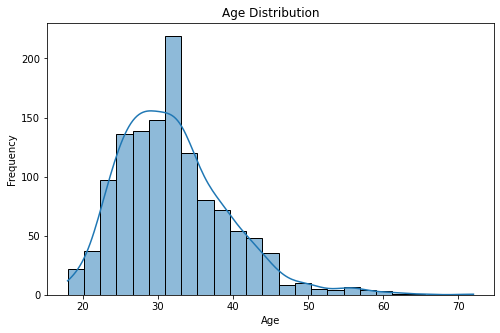

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=25,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

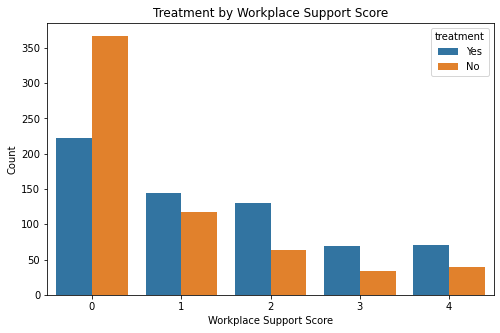

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Workplace_Support_Score",
    hue="treatment"
)

plt.title(
    "Treatment by Workplace Support Score"
)

plt.xlabel("Workplace Support Score")
plt.ylabel("Count")

plt.show()

In [26]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    )
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
Work_Interference_Flag,264,20.969023
work_interfere,264,20.969023
self_employed,18,1.429706
Age,8,0.635425
treatment,0,0.000000
phys_health_consequence,0,0.000000
Family_History_Flag,0,0.000000
Workplace_Support_Score,0,0.000000
Age_Group,0,0.000000
obs_consequence,0,0.000000


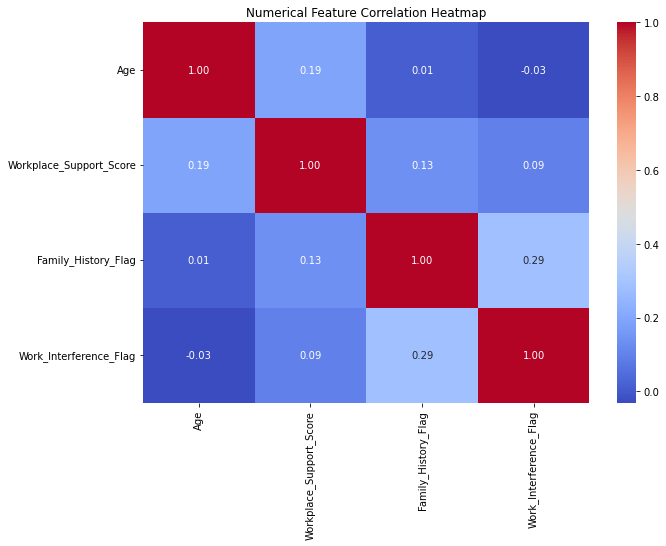

In [27]:
numeric_eda = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_eda.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Numerical Feature Correlation Heatmap")

plt.show()

In [28]:
X = df.drop(
    columns=["treatment"]
)

y = df["treatment"].map({
    "Yes": 1,
    "No": 0
})

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (1259, 26)
y shape: (1259,)

Target distribution:
1    637
0    622
Name: treatment, dtype: int64


In [29]:
class_distribution = pd.DataFrame({
    "Count": y.value_counts(),
    "Percentage": y.value_counts(normalize=True) * 100
})

class_distribution

,Count,Percentage
1,637,50.595711
0,622,49.404289


In [30]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (881, 26)
Validation: (189, 26)
Test: (189, 26)


In [31]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
1    0.506243
0    0.493757
Name: treatment, dtype: float64

Validation distribution:
1    0.507937
0    0.492063
Name: treatment, dtype: float64

Test distribution:
1    0.502646
0    0.497354
Name: treatment, dtype: float64


In [32]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Workplace_Support_Score', 'Family_History_Flag', 'Work_Interference_Flag']

Categorical features:
['Gender', 'self_employed', 'family_history', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'Age_Group']


In [33]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )
    )
])

In [34]:
preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_features
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])

In [35]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [36]:
def evaluate_model(
    model,
    X_data,
    y_data,
    model_name
):

    predictions = model.predict(
        X_data
    )

    probabilities = model.predict_proba(
        X_data
    )[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_data,
            predictions
        ),
        "Precision": precision_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_data,
            probabilities
        )
    }

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        classification_report(
            y_data,
            predictions,
            zero_division=0
        )
    )

    return results

**DECISION TREE**

In [37]:
baseline_model = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "model",
        DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced"
        )
    )
])

baseline_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Workplace_Support_Score',
                                                   'Family_History_Flag',
                                                   'Work_Interference_Flag']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                               

In [38]:
baseline_val = evaluate_model(
    baseline_model,
    X_val,
    y_val,
    "Decision Tree"
)

baseline_val


Decision Tree
              precision    recall  f1-score   support

           0       0.66      0.74      0.70        93
           1       0.72      0.64      0.67        96

    accuracy                           0.69       189
   macro avg       0.69      0.69      0.69       189
weighted avg       0.69      0.69      0.69       189



{'Model': 'Decision Tree',
 'Accuracy': 0.6878306878306878,
 'Precision': 0.7176470588235294,
 'Recall': 0.6354166666666666,
 'F1': 0.6740331491712708,
 'ROC-AUC': 0.6886760752688172}

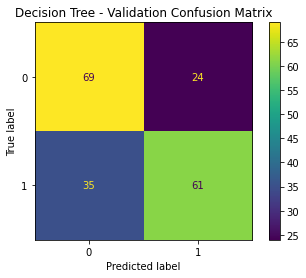

In [39]:
ConfusionMatrixDisplay.from_estimator(
    baseline_model,
    X_val,
    y_val
)

plt.title(
    "Decision Tree - Validation Confusion Matrix"
)

plt.show()

**RANDOM FOREST**

In [40]:
rf_pipeline = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        )
    )
])

In [41]:
rf_param_grid = {
    "model__n_estimators": [
        200,
        400
    ],

    "model__max_depth": [
        None,
        8,
        12
    ],

    "model__min_samples_split": [
        2,
        5
    ],

    "model__min_samples_leaf": [
        1,
        2
    ]
}

In [42]:
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Workplace_Support_Score',
                                                                          'Family_History_Flag',
                                                                       

In [43]:
print(
    "Best Random Forest parameters:"
)

print(
    rf_grid.best_params_
)

print(
    "\nBest cross-validation F1:",
    rf_grid.best_score_
)

Best Random Forest parameters:
{'model__max_depth': 12, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best cross-validation F1: 0.7707366427540221


In [44]:
best_rf = rf_grid.best_estimator_
rf_val = evaluate_model(
    best_rf,
    X_val,
    y_val,
    "Random Forest"
)

rf_val


Random Forest
              precision    recall  f1-score   support

           0       0.72      0.81      0.76        93
           1       0.79      0.70      0.74        96

    accuracy                           0.75       189
   macro avg       0.75      0.75      0.75       189
weighted avg       0.76      0.75      0.75       189



{'Model': 'Random Forest',
 'Accuracy': 0.7513227513227513,
 'Precision': 0.788235294117647,
 'Recall': 0.6979166666666666,
 'F1': 0.7403314917127071,
 'ROC-AUC': 0.8182123655913979}

**XGBOOST**

In [78]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [79]:
try:
    from xgboost import XGBClassifier
    print("XGBoost imported successfully.")
except ImportError:
    print("XGBoost is not installed.")
    print("Run the following in a notebook cell:")
    print("!pip install xgboost")

XGBoost imported successfully.


In [80]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

xgb_pipeline = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "model",
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        )
    )
])

print(xgb_pipeline)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Workplace_Support_Score',
                                                   'Family_History_Flag',
                                                   'Work_Interference_Flag']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                               

In [81]:
xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [2, 3],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(
    X_train,
    y_train
)

print("\nBest XGBoost parameters:")
print(xgb_grid.best_params_)

print("\nBest cross-validation F1:")
print(xgb_grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best XGBoost parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 1.0}

Best cross-validation F1:
0.7661253549464012


In [83]:
best_xgb = xgb_grid.best_estimator_

print("Best XGBoost model:")
print(best_xgb)

Best XGBoost model:
Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Workplace_Support_Score',
                                                   'Family_History_Flag',
                                                   'Work_Interference_Flag']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
           

In [84]:
xgb_val = evaluate_model(
    best_xgb,
    X_val,
    y_val,
    "XGBoost"
)

xgb_val


XGBoost
              precision    recall  f1-score   support

           0       0.74      0.82      0.78        93
           1       0.80      0.72      0.76        96

    accuracy                           0.77       189
   macro avg       0.77      0.77      0.77       189
weighted avg       0.77      0.77      0.77       189



{'Model': 'XGBoost',
 'Accuracy': 0.7671957671957672,
 'Precision': 0.8023255813953488,
 'Recall': 0.71875,
 'F1': 0.7582417582417582,
 'ROC-AUC': 0.8413978494623656}

In [85]:
validation_results = pd.DataFrame([
    baseline_val,
    rf_val,
    xgb_val,
    stack_val
])

validation_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,0.687831,0.717647,0.635417,0.674033,0.688676
1,Random Forest,0.751323,0.788235,0.697917,0.740331,0.818212
2,XGBoost,0.767196,0.802326,0.718750,0.758242,0.841398
3,Stacking Ensemble,0.740741,0.797468,0.656250,0.720000,0.813284


In [86]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        (
            "decision_tree",
            baseline_model
        ),
        (
            "random_forest",
            best_rf
        ),
        (
            "xgboost",
            best_xgb
        )
    ],
    voting="soft",
    n_jobs=-1
)

print(voting_model)

VotingClassifier(estimators=[('decision_tree',
                              Pipeline(steps=[('preprocessing',
                                               ColumnTransformer(transformers=[('num',
                                                                                Pipeline(steps=[('imputer',
                                                                                                 SimpleImputer(strategy='median')),
                                                                                                ('scaler',
                                                                                                 StandardScaler())]),
                                                                                ['Age',
                                                                                 'Workplace_Support_Score',
                                                                                 'Family_History_Flag',
                                     

In [88]:
voting_model.fit(
    X_train,
    y_train
)

print("Voting ensemble trained successfully.")

voting_val = evaluate_model(
    voting_model,
    X_val,
    y_val,
    "Voting Ensemble"
)

voting_val

Voting ensemble trained successfully.

Voting Ensemble
              precision    recall  f1-score   support

           0       0.68      0.77      0.72        93
           1       0.75      0.65      0.69        96

    accuracy                           0.71       189
   macro avg       0.71      0.71      0.71       189
weighted avg       0.71      0.71      0.71       189



{'Model': 'Voting Ensemble',
 'Accuracy': 0.708994708994709,
 'Precision': 0.7469879518072289,
 'Recall': 0.6458333333333334,
 'F1': 0.6927374301675977,
 'ROC-AUC': 0.8155241935483871}

In [89]:
validation_results = pd.DataFrame([
    baseline_val,
    rf_val,
    xgb_val,
    voting_val,
    stack_val
])

validation_results = validation_results.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

display(validation_results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.767196,0.802326,0.718750,0.758242,0.841398
1,Random Forest,0.751323,0.788235,0.697917,0.740331,0.818212
2,Stacking Ensemble,0.740741,0.797468,0.656250,0.720000,0.813284
3,Voting Ensemble,0.708995,0.746988,0.645833,0.692737,0.815524
4,Decision Tree,0.687831,0.717647,0.635417,0.674033,0.688676


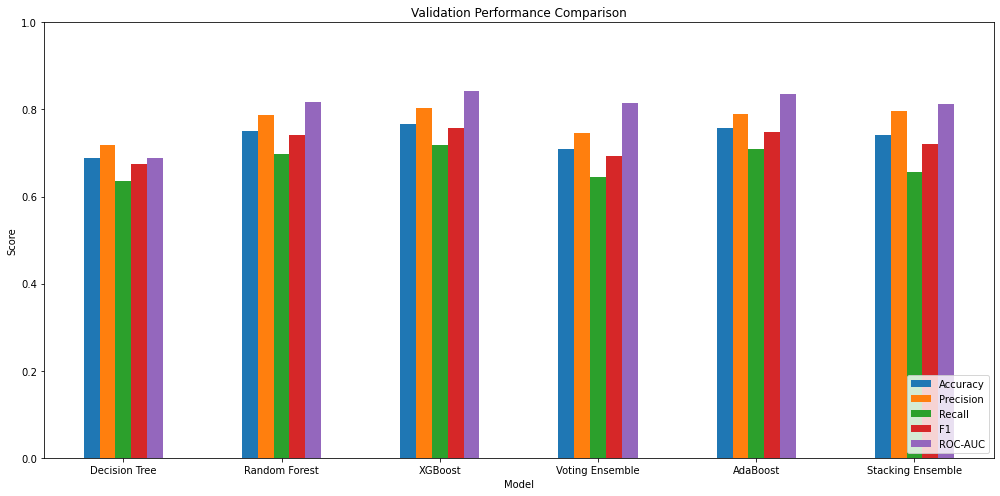

In [116]:
all_validation_results = pd.DataFrame([
    baseline_val,
    rf_val,
    #xgb_val,
    #voting_val,
    ada_val,
    stack_val
])

all_validation_results.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Validation Performance Comparison"
)

plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.show()

In [91]:
best_model_name = validation_results.iloc[0]["Model"]

print("Best model based on validation F1:")
print(best_model_name)

Best model based on validation F1:
XGBoost


Ensemble methods generally improved over the single Decision Tree baseline. XGBoost achieved the strongest overall validation performance and was selected as the final model, with a cross-validation F1-score of approximately 0.766

In [92]:
models_for_test = {
    "Decision Tree": baseline_model,
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "Voting Ensemble": voting_model,
    "Stacking Ensemble": stacking_model
}

test_results = []

for name, model in models_for_test.items():

    result = evaluate_model(
        model,
        X_test,
        y_test,
        name
    )

    test_results.append(result)


test_results_df = pd.DataFrame(test_results)

display(test_results_df)


Decision Tree
              precision    recall  f1-score   support

           0       0.66      0.56      0.61        94
           1       0.62      0.72      0.67        95

    accuracy                           0.64       189
   macro avg       0.64      0.64      0.64       189
weighted avg       0.64      0.64      0.64       189


Random Forest
              precision    recall  f1-score   support

           0       0.76      0.68      0.72        94
           1       0.71      0.79      0.75        95

    accuracy                           0.74       189
   macro avg       0.74      0.74      0.73       189
weighted avg       0.74      0.74      0.73       189


XGBoost
              precision    recall  f1-score   support

           0       0.76      0.73      0.75        94
           1       0.74      0.77      0.76        95

    accuracy                           0.75       189
   macro avg       0.75      0.75      0.75       189
weighted avg       0.75      0.75  

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,0.640212,0.623853,0.715789,0.666667,0.639810
1,Random Forest,0.735450,0.714286,0.789474,0.750000,0.804703
2,XGBoost,0.751323,0.744898,0.768421,0.756477,0.807167
3,Voting Ensemble,0.682540,0.660550,0.757895,0.705882,0.779059
4,Stacking Ensemble,0.714286,0.702970,0.747368,0.724490,0.802240


In [93]:
test_results_df = test_results_df.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

display(test_results_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.751323,0.744898,0.768421,0.756477,0.807167
1,Random Forest,0.735450,0.714286,0.789474,0.750000,0.804703
2,Stacking Ensemble,0.714286,0.702970,0.747368,0.724490,0.802240
3,Voting Ensemble,0.682540,0.660550,0.757895,0.705882,0.779059
4,Decision Tree,0.640212,0.623853,0.715789,0.666667,0.639810


In [94]:
baseline_test = test_results_df[
    test_results_df["Model"] == "Decision Tree"
].iloc[0]

best_test = test_results_df.iloc[0]

print("==========================================")
print("BASELINE VS BEST MODEL")
print("==========================================")

print("\nBaseline: Decision Tree")
print(f"Accuracy : {baseline_test['Accuracy']:.3f}")
print(f"Precision: {baseline_test['Precision']:.3f}")
print(f"Recall   : {baseline_test['Recall']:.3f}")
print(f"F1       : {baseline_test['F1']:.3f}")
print(f"ROC-AUC  : {baseline_test['ROC-AUC']:.3f}")

print(f"\nBest Model: {best_test['Model']}")
print(f"Accuracy : {best_test['Accuracy']:.3f}")
print(f"Precision: {best_test['Precision']:.3f}")
print(f"Recall   : {best_test['Recall']:.3f}")
print(f"F1       : {best_test['F1']:.3f}")
print(f"ROC-AUC  : {best_test['ROC-AUC']:.3f}")

print("\nF1 improvement:")
print(
    f"{(best_test['F1'] - baseline_test['F1']):+.3f}"
)

BASELINE VS BEST MODEL

Baseline: Decision Tree
Accuracy : 0.640
Precision: 0.624
Recall   : 0.716
F1       : 0.667
ROC-AUC  : 0.640

Best Model: XGBoost
Accuracy : 0.751
Precision: 0.745
Recall   : 0.768
F1       : 0.756
ROC-AUC  : 0.807

F1 improvement:
+0.090


Best model: XGBoost

Confusion Matrix:
[[69 25]
 [22 73]]


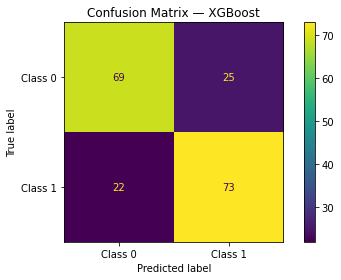

In [95]:
best_name = best_test["Model"]
best_final_model = models_for_test[best_name]

y_test_pred = best_final_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_test_pred
)

print("Best model:", best_name)
print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()

plt.title(
    f"Confusion Matrix — {best_name}"
)

plt.tight_layout()
plt.show()

XGBoost correctly classified 69 negative and 73 positive cases, with 25 false positives and 22 false negatives. The relatively similar false-positive and false-negative counts indicate that neither error type completely dominates the model's mistakes.

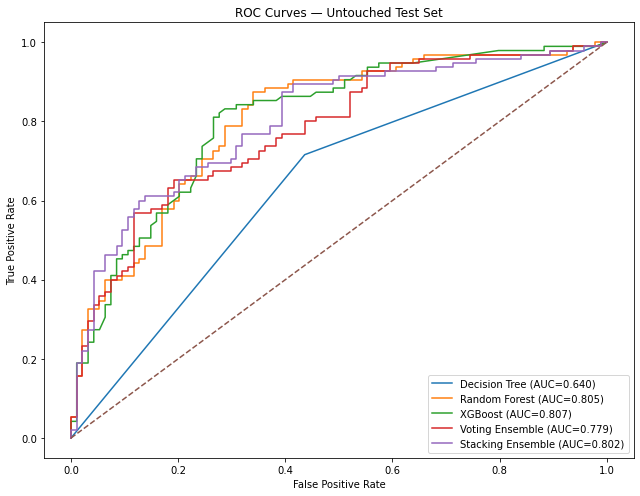

In [96]:
plt.figure(figsize=(9, 7))

for name, model in models_for_test.items():

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_score:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves — Untouched Test Set"
)

plt.legend()
plt.tight_layout()
plt.show()

XGBoost achieved a ROC-AUC of approximately 0.81, indicating good ability to distinguish between the two target classes across classification thresholds.

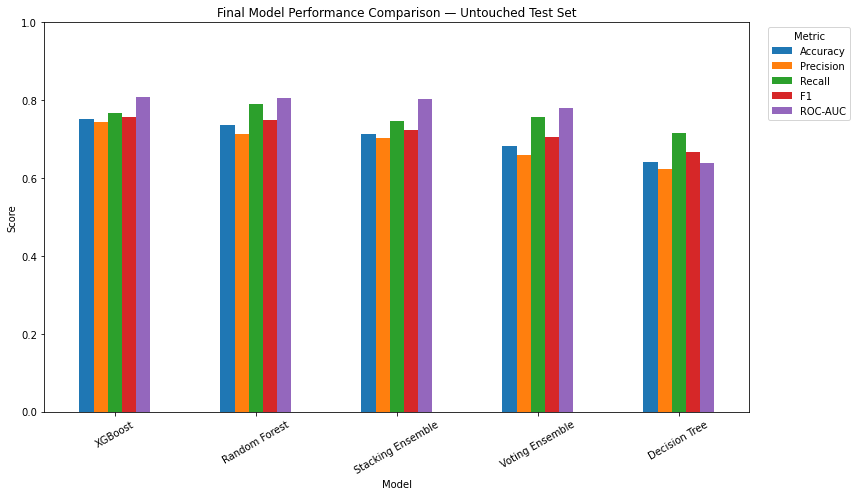

In [97]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

plot_data = test_results_df.set_index(
    "Model"
)[metrics]

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.title(
    "Final Model Performance Comparison — Untouched Test Set"
)

plt.ylim(0, 1)
plt.xticks(rotation=30)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

On the untouched test set, XGBoost achieved approximately 75% accuracy, 75% precision, 77% recall, and 76% F1-score, outperforming the Decision Tree baseline F1 of approximately 0.667. This shows a meaningful improvement from boosting over a single tree.

In [98]:
validation_results.to_csv(
    "validation_model_comparison.csv",
    index=False
)

test_results_df.to_csv(
    "final_test_results.csv",
    index=False
)

print("Results saved:")
print(" - validation_model_comparison.csv")
print(" - final_test_results.csv")

Results saved:
 - validation_model_comparison.csv
 - final_test_results.csv


**SHAP**

In [100]:
xgb_preprocessor = best_xgb.named_steps["preprocessing"]
xgb_model = best_xgb.named_steps["model"]

print("Preprocessor:")
print(type(xgb_preprocessor).__name__)

print("\nXGBoost model:")
print(type(xgb_model).__name__)

Preprocessor:
ColumnTransformer

XGBoost model:
XGBClassifier


In [101]:
X_val_xgb_transformed = xgb_preprocessor.transform(
    X_val
)

if hasattr(X_val_xgb_transformed, "toarray"):
    X_val_xgb_shap = X_val_xgb_transformed.toarray()
else:
    X_val_xgb_shap = np.asarray(
        X_val_xgb_transformed
    )

print(
    "Transformed validation shape:",
    X_val_xgb_shap.shape
)

Transformed validation shape: (189, 74)


In [103]:
xgb_feature_names = get_transformed_feature_names(
    xgb_preprocessor,
    X_val
)

print(
    "Number of XGBoost features:",
    len(xgb_feature_names)
)

print(
    "Actual transformed columns:",
    X_val_xgb_shap.shape[1]
)

if len(xgb_feature_names) == X_val_xgb_shap.shape[1]:
    print("Feature names match.")
else:
    print("Feature name mismatch.")

Number of XGBoost features: 74
Actual transformed columns: 74
Feature names match.


In [104]:
xgb_explainer = shap.TreeExplainer(
    xgb_model
)

print("XGBoost TreeExplainer created successfully.")

xgb_shap_values = xgb_explainer.shap_values(
    X_val_xgb_shap
)

print(
    "SHAP values shape:",
    np.asarray(xgb_shap_values).shape
)

print(
    "Validation data shape:",
    X_val_xgb_shap.shape
)

XGBoost TreeExplainer created successfully.
SHAP values shape: (189, 74)
Validation data shape: (189, 74)


In [105]:
xgb_mean_abs_shap = np.abs(
    xgb_shap_values
).mean(axis=0)

xgb_shap_importance = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Mean_Absolute_SHAP": xgb_mean_abs_shap
})

xgb_shap_importance = (
    xgb_shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    xgb_shap_importance.head(15)
)

,Feature,Mean_Absolute_SHAP
0,Family_History_Flag,0.435877
1,Work_Interference_Flag,0.252736
2,care_options_Yes,0.225543
3,work_interfere_Sometimes,0.120010
4,work_interfere_Often,0.109509
5,Workplace_Support_Score,0.093326
6,family_history_No,0.082688
7,work_interfere_Never,0.059902
8,benefits_Yes,0.042399
9,Gender_Male,0.039386


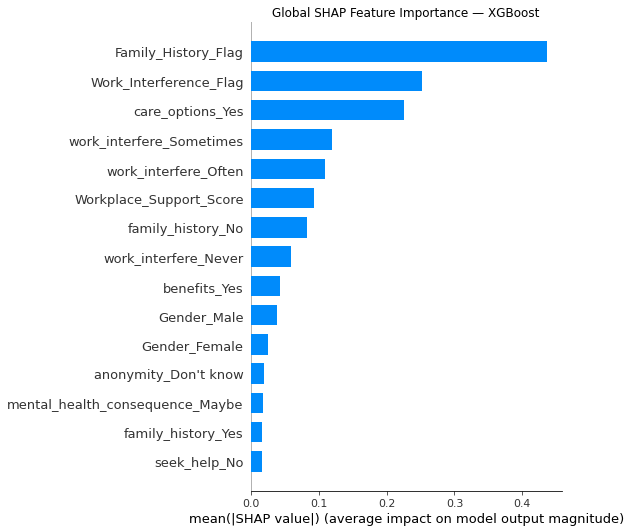

In [106]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    xgb_shap_values,
    X_val_xgb_shap,
    feature_names=xgb_feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title(
    "Global SHAP Feature Importance — XGBoost"
)

plt.tight_layout()
plt.show()

SHAP provides a transparent view of the features driving model predictions. The global importance plot identifies the most influential features, helping connect model behaviour to meaningful workplace and individual factors.

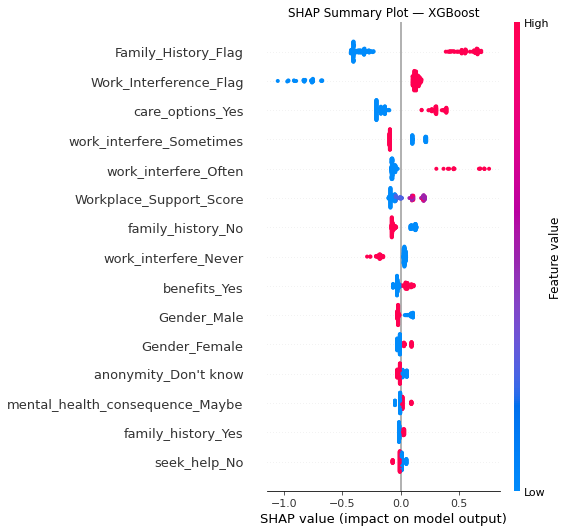

In [107]:
plt.figure(figsize=(11, 8))

shap.summary_plot(
    xgb_shap_values,
    X_val_xgb_shap,
    feature_names=xgb_feature_names,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary Plot — XGBoost"
)

plt.tight_layout()
plt.show()

The SHAP summary plot shows both feature importance and direction of influence. This helps distinguish features that push predictions toward the positive class from those that reduce the predicted probability.

In [108]:

synthetic_employee = X_train.iloc[[0]].copy()

# ------------------------------------------------------------
# Demographic information
# ------------------------------------------------------------

synthetic_employee["Age"] = 29
synthetic_employee["Gender"] = "Female"

# ------------------------------------------------------------
# Mental-health/work-related factors
# ------------------------------------------------------------

synthetic_employee["family_history"] = "Yes"
synthetic_employee["work_interfere"] = "Often"

# ------------------------------------------------------------
# Workplace support
# ------------------------------------------------------------

synthetic_employee["benefits"] = "Yes"
synthetic_employee["care_options"] = "Yes"
synthetic_employee["wellness_program"] = "No"
synthetic_employee["seek_help"] = "Yes"
synthetic_employee["anonymity"] = "Don't know"

# ------------------------------------------------------------
# Work characteristics
# ------------------------------------------------------------

synthetic_employee["remote_work"] = "No"
synthetic_employee["tech_company"] = "Yes"

# ------------------------------------------------------------
# Engineered features
# ------------------------------------------------------------

synthetic_employee["Family_History_Flag"] = 1
synthetic_employee["Work_Interference_Flag"] = 1
synthetic_employee["Workplace_Support_Score"] = 2
synthetic_employee["Age_Group"] = "25-34"

print("Synthetic employee:")
display(synthetic_employee.T)

Synthetic employee:


,773
Age,29
Gender,Female
self_employed,No
family_history,Yes
work_interfere,Often
no_employees,More than 1000
remote_work,No
tech_company,Yes
benefits,Yes
care_options,Yes


In [109]:
synthetic_prediction = best_xgb.predict(
    synthetic_employee
)[0]

synthetic_probability = best_xgb.predict_proba(
    synthetic_employee
)[0, 1]

print("==========================================")
print("SYNTHETIC EMPLOYEE PREDICTION")
print("==========================================")

if synthetic_prediction == 1:
    print("Prediction: Treatment likely")
else:
    print("Prediction: Treatment not predicted")

print(
    f"Treatment probability: "
    f"{synthetic_probability:.2%}"
)

print(
    f"No-treatment probability: "
    f"{1 - synthetic_probability:.2%}"
)

print("\nThis is a model prediction, not a diagnosis.")

SYNTHETIC EMPLOYEE PREDICTION
Prediction: Treatment likely
Treatment probability: 87.20%
No-treatment probability: 12.80%

This is a model prediction, not a diagnosis.


For the synthetic employee, XGBoost predicted “Treatment likely” with an 87.20% probability. This demonstrates how the trained model can generate an individual prediction from a realistic feature profile.

In [110]:
synthetic_xgb_transformed = (
    xgb_preprocessor.transform(
        synthetic_employee
    )
)

if hasattr(
    synthetic_xgb_transformed,
    "toarray"
):
    synthetic_xgb_shap = (
        synthetic_xgb_transformed.toarray()
    )
else:
    synthetic_xgb_shap = np.asarray(
        synthetic_xgb_transformed
    )

print(
    "Synthetic transformed shape:",
    synthetic_xgb_shap.shape
)

Synthetic transformed shape: (1, 74)


In [111]:
synthetic_xgb_shap_values = (
    xgb_explainer.shap_values(
        synthetic_xgb_shap
    )
)

local_xgb_shap_values = (
    synthetic_xgb_shap_values[0]
)

print(
    "Number of local SHAP values:",
    len(local_xgb_shap_values)
)

Number of local SHAP values: 74


In [112]:
local_xgb_explanation = pd.DataFrame({
    "Feature": xgb_feature_names,
    "SHAP_Value": local_xgb_shap_values,
    "Absolute_SHAP": np.abs(
        local_xgb_shap_values
    )
})

local_xgb_explanation = (
    local_xgb_explanation
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

local_xgb_explanation["Effect"] = np.where(
    local_xgb_explanation["SHAP_Value"] > 0,
    "Increases treatment prediction",
    "Decreases treatment prediction"
)

display(
    local_xgb_explanation.head(10)
)

,Feature,SHAP_Value,Absolute_SHAP,Effect
0,work_interfere_Often,0.413546,0.413546,Increases treatment prediction
1,Family_History_Flag,0.354933,0.354933,Increases treatment prediction
2,care_options_Yes,0.295603,0.295603,Increases treatment prediction
3,work_interfere_Sometimes,0.215375,0.215375,Increases treatment prediction
4,Work_Interference_Flag,0.162502,0.162502,Increases treatment prediction
5,Workplace_Support_Score,0.110998,0.110998,Increases treatment prediction
6,Gender_Female,0.090559,0.090559,Increases treatment prediction
7,benefits_Yes,0.086544,0.086544,Increases treatment prediction
8,family_history_No,0.077065,0.077065,Increases treatment prediction
9,Gender_Male,0.070561,0.070561,Increases treatment prediction


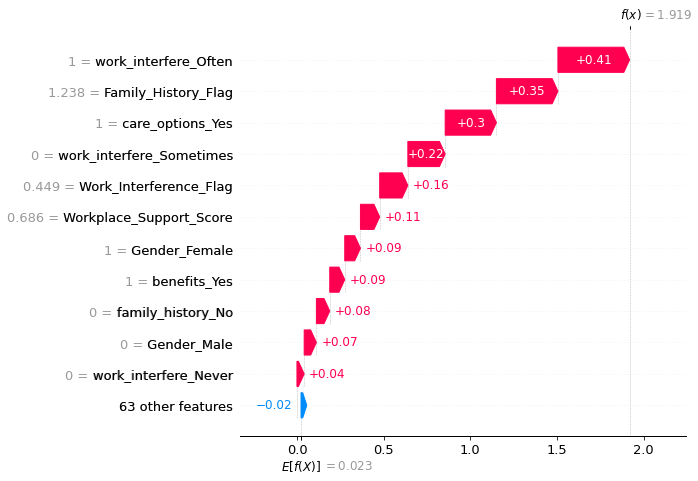

In [113]:
xgb_expected_value = (
    xgb_explainer.expected_value
)

local_explanation_object = shap.Explanation(
    values=local_xgb_shap_values,
    base_values=xgb_expected_value,
    data=synthetic_xgb_shap[0],
    feature_names=xgb_feature_names
)

shap.plots.waterfall(
    local_explanation_object,
    max_display=12
)

The local SHAP explanation identifies the features that contributed most strongly to this individual prediction, showing which factors increased or decreased the predicted probability. This makes the individual prediction more interpretable rather than treating the model as a black box.

In [114]:
top5_local = local_xgb_explanation.head(5)

print("==========================================")
print("TOP 5 FACTORS BEHIND THE PREDICTION")
print("==========================================")

for _, row in top5_local.iterrows():

    direction = (
        "increased"
        if row["SHAP_Value"] > 0
        else "decreased"
    )

    print(
        f"- {row['Feature']}: "
        f"{direction} the treatment prediction "
        f"(SHAP = {row['SHAP_Value']:.4f})"
    )

TOP 5 FACTORS BEHIND THE PREDICTION
- work_interfere_Often: increased the treatment prediction (SHAP = 0.4135)
- Family_History_Flag: increased the treatment prediction (SHAP = 0.3549)
- care_options_Yes: increased the treatment prediction (SHAP = 0.2956)
- work_interfere_Sometimes: increased the treatment prediction (SHAP = 0.2154)
- Work_Interference_Flag: increased the treatment prediction (SHAP = 0.1625)


In [115]:
validation_results.to_csv(
    "validation_model_comparison.csv",
    index=False
)

test_results_df.to_csv(
    "final_test_results.csv",
    index=False
)

xgb_shap_importance.to_csv(
    "xgb_global_shap_importance.csv",
    index=False
)

local_xgb_explanation.to_csv(
    "xgb_local_shap_explanation.csv",
    index=False
)

print("All result files saved successfully.")

All result files saved successfully.


**ADABOOST**

In [45]:
ada_base_tree = DecisionTreeClassifier(
    max_depth=2,
    random_state=RANDOM_STATE
)
ada_pipeline = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "model",
        AdaBoostClassifier(
            base_estimator=ada_base_tree,
            random_state=RANDOM_STATE
        )
    )
])

In [46]:
ada_param_grid = {
    "model__n_estimators": [
        50,
        100,
        200,
        300
    ],

    "model__learning_rate": [
        0.01,
        0.05,
        0.1,
        0.5,
        1.0
    ],

    "model__base_estimator__max_depth": [
        1,
        2,
        3
    ]
}

In [47]:
ada_grid = GridSearchCV(
    estimator=ada_pipeline,
    param_grid=ada_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

ada_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Workplace_Support_Score',
                                                                          'Family_History_Flag',
                                                                       

In [48]:
print(
    "Best AdaBoost parameters:"
)

print(
    ada_grid.best_params_
)

print(
    "\nBest cross-validation F1:",
    ada_grid.best_score_
)

Best AdaBoost parameters:
{'model__base_estimator__max_depth': 1, 'model__learning_rate': 0.05, 'model__n_estimators': 200}

Best cross-validation F1: 0.7709796961117139


In [49]:
best_ada = ada_grid.best_estimator_
ada_val = evaluate_model(
    best_ada,
    X_val,
    y_val,
    "AdaBoost"
)

ada_val


AdaBoost
              precision    recall  f1-score   support

           0       0.73      0.81      0.77        93
           1       0.79      0.71      0.75        96

    accuracy                           0.76       189
   macro avg       0.76      0.76      0.76       189
weighted avg       0.76      0.76      0.76       189



{'Model': 'AdaBoost',
 'Accuracy': 0.7566137566137566,
 'Precision': 0.7906976744186046,
 'Recall': 0.7083333333333334,
 'F1': 0.7472527472527473,
 'ROC-AUC': 0.8361895161290324}

In [50]:
ensemble_validation_results = pd.DataFrame([
    baseline_val,
    rf_val,
    ada_val
])

ensemble_validation_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,0.687831,0.717647,0.635417,0.674033,0.688676
1,Random Forest,0.751323,0.788235,0.697917,0.740331,0.818212
2,AdaBoost,0.756614,0.790698,0.708333,0.747253,0.836190


In [51]:
tree_stack = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "model",
        DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

In [52]:
rf_stack = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

In [53]:
ada_stack = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "model",
        AdaBoostClassifier(
            base_estimator=DecisionTreeClassifier(
                max_depth=2,
                random_state=RANDOM_STATE
            ),
            n_estimators=100,
            learning_rate=0.1,
            random_state=RANDOM_STATE
        )
    )
])

In [54]:
stacking_model = StackingClassifier(
    estimators=[
        ("tree", tree_stack),
        ("rf", rf_stack),
        ("ada", ada_stack)
    ],

    final_estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),

    cv=cv,

    stack_method="predict_proba",

    n_jobs=-1
)

In [55]:
stacking_model.fit(
    X_train,
    y_train
)
stack_val = evaluate_model(
    stacking_model,
    X_val,
    y_val,
    "Stacking Ensemble"
)

stack_val


Stacking Ensemble
              precision    recall  f1-score   support

           0       0.70      0.83      0.76        93
           1       0.80      0.66      0.72        96

    accuracy                           0.74       189
   macro avg       0.75      0.74      0.74       189
weighted avg       0.75      0.74      0.74       189



{'Model': 'Stacking Ensemble',
 'Accuracy': 0.7407407407407407,
 'Precision': 0.7974683544303798,
 'Recall': 0.65625,
 'F1': 0.7200000000000001,
 'ROC-AUC': 0.8132840501792115}